<h1 style='color: RGB(27, 169, 127); font-size: 50pt';>PAP 2.2 – Python-Auswertung</h1>

## Wichtige Funktionen für das PAP.

Alle in diesem Dokument geschriebenen Zeilen Code sind von mir eigenständig geschrieben. Für ein sauberes und struktiriertes Dokument wurde eine eigene Pythonlibary geschrieben, welche insbesondere ans PAP angepasst wurde. Dieses ist unter dem Namen 'Papulator' auf meinem GitHub zu finden. Diese soll setig ausgearbeitet werden. Der Stand dieses Protokolls ist der 29.04.2026.
 
----

# Inhaltsverzeichnis zur Auswertung
* [Definition der Versuchsvariablen](#Definition-der-Versuchsvariablen)
* [Import aller genutzen Libaries](#Import-aller-genutzen-Libaries)
* [Auswertung der Aufgaben](#Auswertung-der-Aufgaben)
    * [Aufgabe 1](#Aufgabe-1)
    * [Aufgabe 2](#Aufgabe-2)
    * [Aufgabe 3](#Aufgabe-3)
    * [Aufgabe 4](#Aufgabe-4)
    * [Aufgabe 5](#Aufgabe-5)
    * [Aufgabe 6](#Aufgabe-6)


---
---

# Definition der Versuchsvariablen

Im Folgenden sind Versuchsvariablen definiert, die für einen besseren Workflow sorgen sollen. Diese werden zum exportieren und überschreiben von Dateien wichtig sein und ermöglichen es, diese Datei für jeden Versuch zu benutzen und lediglich die Variablen zu verändern. Es ist jedoch empfohlen eine Kopie der Forlage für jeden Versuch zu machen, damit dieses Dokument strukturiert bleibt.

Zudem sind wichtige Konstanten definiert, die immer wieder auftauchen.

In [86]:
versuchsnummer = '241'
versuchsname = 'RLC-Glieder' # Auf Leerzeichen verzichten
aufgabe = '0z'
plt_save_folder = f'../img/plots/'

# Import aller genutzen Libaries

In [87]:
# Eigene Pythonlibary für das Pap
import Papulator as pap
from Papulator import Colors as c
from Papulator import Sympy_Symbols as sym

# Numpy für bessere Berechnungen
import numpy as np
from numpy import exp, sqrt, log, pi
from uncertainties import unumpy as unp

# Weiteres für bessere Rechnungen
import pylab as py

import math

# Berechnungen und Plotting
from scipy import odr
import scipy.optimize
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.stats import chi2
from scipy.stats import poisson
from scipy.signal import find_peaks
from scipy.signal import argrelextrema, argrelmin, argrelmax
from scipy.special import factorial
from scipy.integrate import quad

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.transforms as transforms

# Zum Auslesen von Dateien und ähnlichem
import os
import os.path

import pandas as pd
import csv
import re

# Besseres Funktionen handling
import sympy as sp
from sympy import separatevars

<hr>
<hr>

# Auswertung der Aufgaben

In [212]:
def plot_channels(file_path: str, title: str = None, safe: str = None):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    # Extract metadata
    time_step = 1.0
    time_unit = "s"
    ch_scales = {}

    for line in lines:
        match = re.search(r'(\d+)\s*=\s*([\d.]+)\s*(\w+)', line)
        if match and time_step == 1.0:
            _, scale, unit = match.groups()
            time_step = float(scale)
            time_unit = unit

        ch_match = re.search(r'(CH\d):\s*(\d+)\s*=\s*([\d.]+)\s*V', line)
        if ch_match:
            ch, counts_per_div, volts_per_div = ch_match.groups()
            ch_scales[ch] = (float(counts_per_div), float(volts_per_div))

    # Load numeric data
    data_start = 10
    data = np.loadtxt(lines[data_start:])

    time_index = data[:, 0]
    ch1_raw = data[:, 1]
    ch2_raw = data[:, 2]

    # Convert to actual units
    time = time_index * time_step

    def convert_channel(raw, scale_tuple):
        counts_per_div, volts_per_div = scale_tuple
        return (raw / counts_per_div) * volts_per_div

    ch1 = convert_channel(ch1_raw, ch_scales.get('CH1', (1, 1)))
    ch2 = convert_channel(ch2_raw, ch_scales.get('CH2', (1, 1)))

    plt.figure(figsize=(10, 5))
    ax = plt.gca()

    # Plot data
    ax.plot(time, ch1, label=f"CH1 ({ch_scales.get('CH1', ('?', '?'))[1]} V/div)")
    ax.plot(time, ch2, label=f"CH2 ({ch_scales.get('CH2', ('?', '?'))[1]} V/div)")

    # Scope divisions (13x8 grid)
    x_divs = 13
    y_divs = 8

    x_ticks = np.linspace(time.min(), time.max(), x_divs + 1)
    y_ticks = np.linspace(min(ch1.min(), ch2.min()),
                          max(ch1.max(), ch2.max()),
                          y_divs + 1)

    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)

    # exact grid limits
    ax.set_xlim(x_ticks[0], x_ticks[-1])
    ax.set_ylim(y_ticks[0], y_ticks[-1])

    # Midline
    y_min, y_max = ax.get_ylim()
    ax.axhline((y_min + y_max) / 2, color=c.WINE_RED, linewidth=1, label='Mittellinie')

    # hide numbers 
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    # Labels + title
    ax.set_title(title if title else None)


    x_range = time.max() - time.min()
    x_res_per_div = x_range / x_divs

    # ax.set_xlabel(f"Time [{time_unit}] ({x_res_per_div:.3g} {time_unit}/div)")
    ax.set_xlabel(f"Time [{time_unit}] ({time_step:.3g} {time_unit}/div)")
    ax.set_ylabel("Voltage [V]")

    ax.legend()

    # ax.set_xlim(19500, 25000)

    if safe:
        plt.savefig(f'{plt_save_folder}{safe}_{aufgabe}.pdf', dpi=300)

    # pap.plot_me()

    plt.show()


In [152]:
V_step_err = 3
t_step_err = 5

def calc_step_err(voltage_div, time_div):
    voltage_step = voltage_div / 32
    time_Step = time_div / 50

    return voltage_step * V_step_err, time_Step * t_step_err

<hr>

## Aufgabe 1

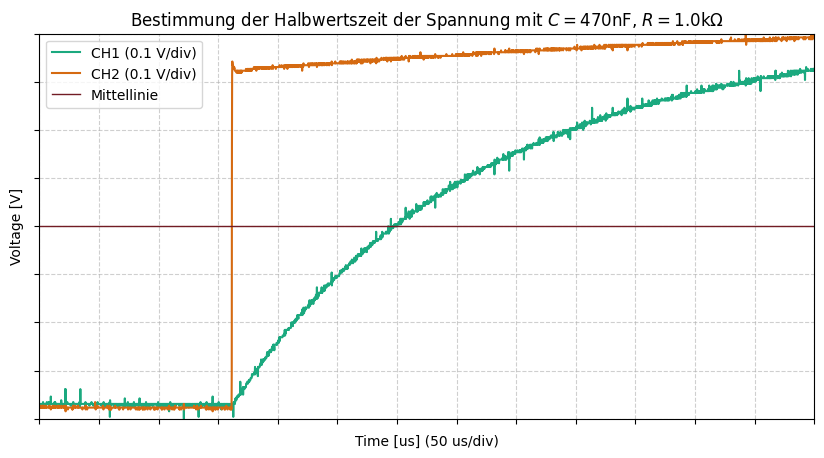

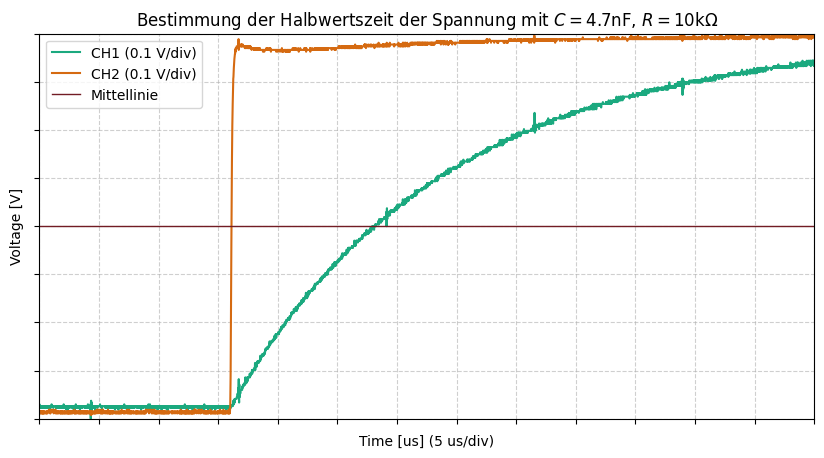

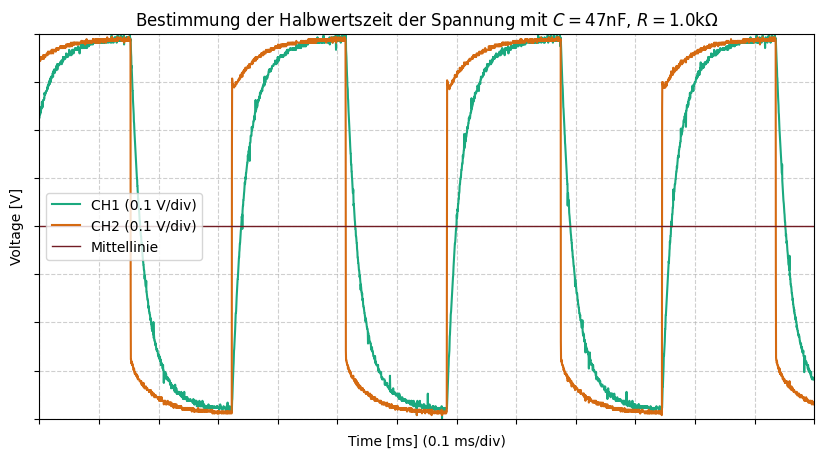

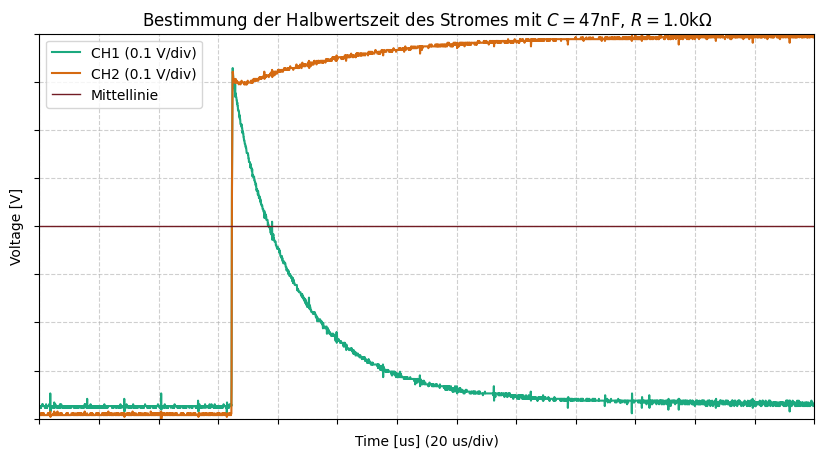

In [ ]:
# aufgabe = '1a'

# plot_channels('./A1/M1.txt', r'Bestimmung der Halbwertszeit der Spannung mit $C = 470$nF, $R = 1.0\mathrm{k}\Omega$', safe='M1')

# plot_channels('./A1/M2.txt', r'Bestimmung der Halbwertszeit der Spannung mit $C = 4.7$nF, $R = 10\mathrm{k}\Omega$', safe='M2')

# plot_channels('./A1/M3.txt', r'Bestimmung der Halbwertszeit der Spannung mit $C = 47$nF, $R = 1.0\mathrm{k}\Omega$', safe='M3')

# plot_channels('./A1/M4.txt', r'Bestimmung der Halbwertszeit des Stromes mit $C = 47$nF, $R = 1.0\mathrm{k}\Omega$', safe='M4')

In [214]:
# M1: 0.1 V/div, 50 us/div
v_s_err, t_s_err = calc_step_err(0.1, 50)
M1_res = pap.round_sig_digs(t_s_err, 376)

print(f'Für M1 ergibt sich eine Halbwertszeit von: {M1_res[2]} us')

# M2: 0.1 V/div, 5 us/div
v_s_err, t_s_err = calc_step_err(0.1, 5)
M2_res = pap.round_sig_digs(t_s_err, 31.2)

print(f'Für M2 ergibt sich eine Halbwertszeit von: {M2_res[2]} us')

# M3: 0.1 V/div, 5 us/div
v_s_err, t_s_err = calc_step_err(0.1, 5)
M3_res = pap.round_sig_digs(t_s_err, 39.7)

print(f'Für M3 ergibt sich eine Halbwertszeit von: {M3_res[2]} us')

# M4: 0.1 V/div, 20 us/div
v_s_err, t_s_err = calc_step_err(0.1, 20)
M4_res = pap.round_sig_digs(t_s_err, 30.2)

print(f'Für M4 ergibt sich eine Halbwertszeit von: {M4_res[2]} us')

Für M1 ergibt sich eine Halbwertszeit von: 376 \pm 5 us
Für M2 ergibt sich eine Halbwertszeit von: 31.2 \pm 0.5 us
Für M3 ergibt sich eine Halbwertszeit von: 39.7 \pm 0.5 us
Für M4 ergibt sich eine Halbwertszeit von: 30.2 \pm 2.0 us


<hr>

## Aufgabe 2

<hr>

## Aufgabe 3

<hr>

## Aufgabe 4

<hr>

## Aufgabe 5

<hr>

## Aufgabe 6

<hr>

## Aufgabe 7

<hr>

## Aufgabe 8